In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
 #loading dataset
df = pd.read_csv("../Data/EstateProductivityPrediction_dataset.csv")

In [3]:
#null/missing values
df['irradiance_SW_DWN']= df['irradiance_SW_DWN'].replace(-999, np.nan)   #sentinal value
df.isnull().sum()

year                   0
month                  0
month_num              0
wet_days               6
rainfall               6
male_workforce       105
female_workforce     105
temperature_T2M        0
irradiance_SW_DWN      1
yield                 19
dtype: int64

In [4]:
#handling missing values of the rainfall and wet days column
df['rainfall']=(df.groupby('month')['rainfall'].transform(lambda x: x.fillna(x.median())))         #median because rainfall is skewed

df['wet_days']=(df.groupby('month')['wet_days'].transform(lambda x: x.fillna(x.mean())))

# Month-wise MEDIAN imputation for yield-you can try out imputation by using knn, interpolation (forward and backward fill)
df['yield'] = (
    df.groupby('month')['yield']
      .transform(lambda x: x.fillna(x.median()))
)

#handling missing values in labour data
df['male_workforce']= (df.groupby('year')['male_workforce'].transform(lambda x: x.fillna(x.dropna().iloc[0])))

df['female_workforce']= (df.groupby('year')['female_workforce'].transform(lambda x: x.fillna(x.dropna().iloc[0])))

#sentinal value in shortwave irradiance
df['irradiance_SW_DWN']=(df.groupby('month')['irradiance_SW_DWN'].transform(lambda x: x.fillna(x.median())))

# Final check
df.isnull().sum()

year                 0
month                0
month_num            0
wet_days             0
rainfall             0
male_workforce       0
female_workforce     0
temperature_T2M      0
irradiance_SW_DWN    0
yield                0
dtype: int64

In [5]:
#handling correlation between male and female workforce

#creatine a total workforce column
df['total_workforce']=df['female_workforce']+df['male_workforce']

#creating female workforce as a ratio
df['female_workforceRatio']=df['female_workforce']/df['total_workforce']

df.drop(['male_workforce','female_workforce'], axis=1, inplace=True)

# Quick verification
print(df[['total_workforce', 'female_workforceRatio']].head())

   total_workforce  female_workforceRatio
0            901.0               0.560488
1            901.0               0.560488
2            901.0               0.560488
3            901.0               0.560488
4            901.0               0.560488


In [6]:
#adding lags
df = df.sort_values(['year', 'month_num']).reset_index(drop=True)
df['yield_lag_1']=df['yield'].shift(1)
df['yield_lag_2']=df['yield'].shift(2)
df['yield_lag_3']=df['yield'].shift(3)

#rainfall lag
df['rainfall_lag_1']= df['rainfall'].shift(1)

#remove rows with missing lags
df=df.dropna().reset_index(drop=True)

In [7]:
##new 15.02.2026- adding the code to show seasonality
df["sin_month"] = np.sin(2 * np.pi * df["month_num"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["month_num"] / 12)

df = df.drop(columns=["month_num"])


In [8]:
#the next dataset
df2=pd.read_csv('../Data/Estate_NDVI_Monthly_2016_2025_all_months.csv')

In [9]:
ndvi_aligned = df2['NDVI'].iloc[3:].reset_index(drop=True)
df['NDVI']=ndvi_aligned

In [10]:
#imputing the NVDI column using month wise median
month_median_ndvi = df.groupby('month')['NDVI'].median()

#filling missing values using median
df['NDVI'] = df.apply(lambda row:month_median_ndvi[row['month']] if pd.isna(row['NDVI']) else row['NDVI'],axis=1)

In [11]:
df.loc[df['NDVI'] < 0.2, 'NDVI'] = \
    df.loc[df['NDVI'] < 0.2, 'month'].map(month_median_ndvi)

In [12]:
features = ['rainfall','wet_days','temperature_T2M','irradiance_SW_DWN','total_workforce','female_workforceRatio','yield_lag_1','yield_lag_2','yield_lag_3','rainfall_lag_1','sin_month','cos_month','NDVI']    #added sin_month and cos_month to features-15.02.2026

target = ['yield']
X=df[features]
Y=df[target]

In [13]:
split_idx=int(len(df)*0.8)
x_train = X.iloc[:split_idx]
y_train = Y.iloc[:split_idx]

x_test = X.iloc[split_idx:]
y_test = Y.iloc[split_idx:]


In [14]:
#initializing scaler
scaler = StandardScaler()
#scaling training data
x_train_scaled = scaler.fit_transform(x_train)
#scaling testing data
x_test_scaled = scaler.transform(x_test)

In [15]:
# Convert back to DataFrame (optional but clean)
X_train_scaled = pd.DataFrame(x_train_scaled, columns=features, index=x_train.index)
X_test_scaled = pd.DataFrame(x_test_scaled, columns=features, index=x_test.index)

In [16]:
#catboost model
cat_model = CatBoostRegressor(iterations = 1000,
                              learning_rate = 0.05,
                              depth = 6,
                              loss_function = 'RMSE',
                              eval_metric = 'RMSE',
                              random_seed = 42,
                              verbose = 100)

#fit model
cat_model.fit(x_train_scaled, y_train,eval_set = (x_test_scaled, y_test),early_stopping_rounds = 50)

0:	learn: 13891.5018093	test: 11714.8307960	best: 11714.8307960 (0)	total: 123ms	remaining: 2m 2s
100:	learn: 4987.7787181	test: 9758.6836194	best: 9743.8046215 (99)	total: 273ms	remaining: 2.43s
200:	learn: 2092.4173123	test: 9607.3743235	best: 9467.3575494 (152)	total: 420ms	remaining: 1.67s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 9467.357549
bestIteration = 152

Shrink model to first 153 iterations.


In [17]:
y_pred_cat = cat_model.predict(x_test_scaled)

In [18]:
mse = mean_squared_error(y_test, y_pred_cat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_cat)
r2 = r2_score(y_test, y_pred_cat)

print("CatBoost Yield Prediction Performance")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")


CatBoost Yield Prediction Performance
RMSE: 9467.36
MAE : 7800.38
R²  : -0.003


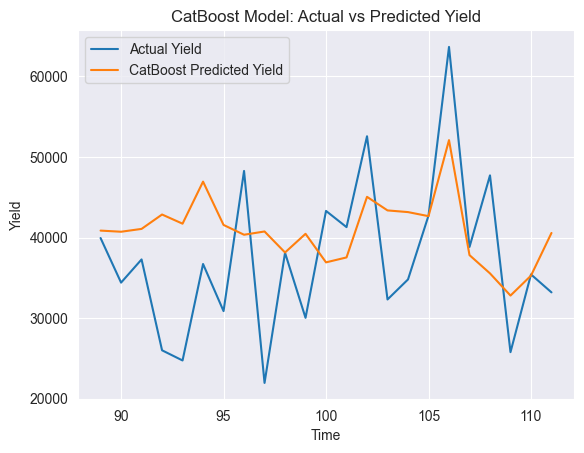

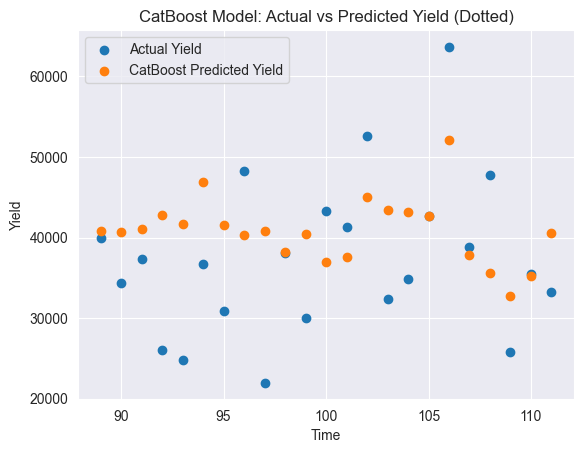

In [19]:
#line plot
plt.figure()

plt.plot(y_test.index, y_test.values, label="Actual Yield")
plt.plot(y_test.index, y_pred_cat, label="CatBoost Predicted Yield")

plt.legend()
plt.title("CatBoost Model: Actual vs Predicted Yield")
plt.xlabel("Time")
plt.ylabel("Yield")

plt.show()

#scatter plot
plt.figure()

plt.scatter(y_test.index, y_test.values,
            label="Actual Yield")

plt.scatter(y_test.index, y_pred_cat,
            label="CatBoost Predicted Yield")

plt.legend()
plt.title("CatBoost Model: Actual vs Predicted Yield (Dotted)")
plt.xlabel("Time")
plt.ylabel("Yield")

plt.show()

In [20]:
#XGBoost on the dataset with ndvi
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(x_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [21]:
y_pred_xgb = xgb_model.predict(x_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae  = mean_absolute_error(y_test, y_pred_xgb)
r2   = r2_score(y_test, y_pred_xgb)

print("Model A — XGBoost Yield Prediction")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")

Model A — XGBoost Yield Prediction
RMSE: 9548.15
MAE : 7639.46
R²  : -0.020


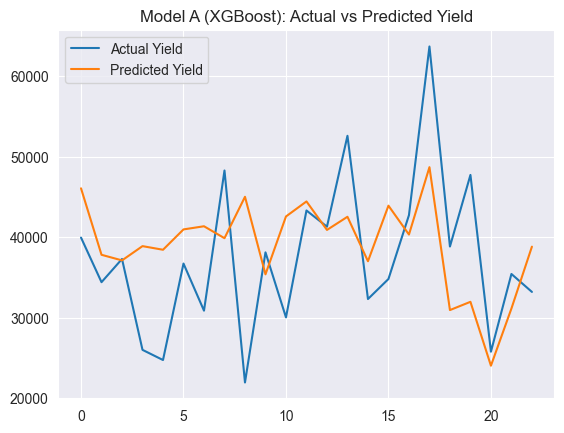

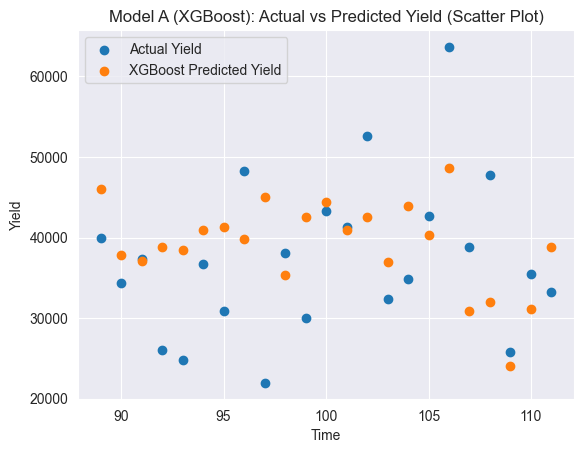

In [22]:
plt.figure()
plt.plot(y_test.values, label="Actual Yield")
plt.plot(y_pred_xgb, label="Predicted Yield")
plt.legend()
plt.title("Model A (XGBoost): Actual vs Predicted Yield")
plt.show()

plt.figure()

#scatter plot
plt.scatter(y_test.index, y_test.values, label="Actual Yield")
plt.scatter(y_test.index, y_pred_xgb, label="XGBoost Predicted Yield")
plt.legend()
plt.title("Model A (XGBoost): Actual vs Predicted Yield (Scatter Plot)")
plt.xlabel("Time")
plt.ylabel("Yield")
plt.show()



In [23]:
#trying a basic ensemble method with xgboost and catboost
y_pred_avg = (y_pred_xgb+y_pred_cat)/2

mse = mean_squared_error(y_test, y_pred_avg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_avg)
r2 = r2_score(y_test, y_pred_avg)

print("Ensemble (XGBoost + CatBoost) Performance")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.3f}")

Ensemble (XGBoost + CatBoost) Performance
RMSE: 9256.77
MAE : 7586.35
R²  : 0.042
